In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# import seaborn as sns
import tensorflow as tf
# import math
# import datetime
# import platform

**Problem Statement:**

This assignment challenges students to construct and train a neural network to
accurately classify handwritten digits from the MNIST dataset. The goal is to
navigate through the preprocessing of image data, select an appropriate neural
network architecture, and apply optimization techniques to achieve high
classification accuracy.


**Data Preprocessing:**

Prepare the MNIST dataset for training and testing the
neural network model. This includes normalization of image pixel values and
converting the output labels to a one-hot encoded format.


In [2]:
mnist_ds = tf.keras.datasets.mnist

In [3]:
(x_train,y_train), (x_test, y_test) = mnist_ds.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
print(x_train.shape, y_train.shape) # 60k samples for training
print(x_test.shape, y_test.shape) # 10k samples for testing

(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


In [5]:
x_train.ndim # 3 dimension array
pd.DataFrame(x_train[1])
# 28 X 28 - one digit's pixel form - 0 to 255 for gray scale

,0,1,2,3,4,5,6,7,8,9,...,18,19,20,21,22,23,24,25,26,27
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,159,50,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,252,237,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,...,233,252,57,6,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,...,84,252,253,122,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,...,96,189,253,167,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,0,...,47,79,255,168,0,0,0,0,0,0


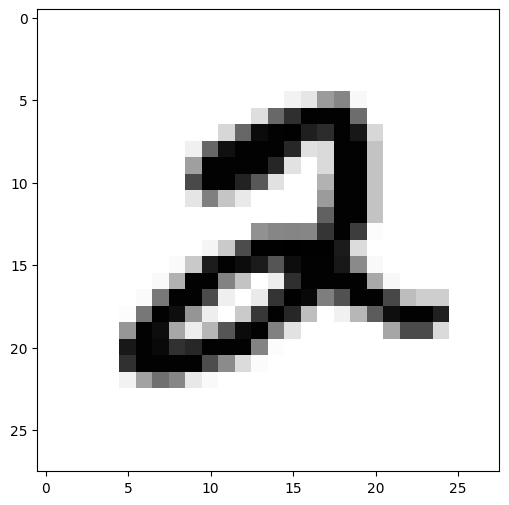

In [6]:
plt.figure(figsize=(6,6))
plt.imshow(x_train[5], cmap=plt.cm.binary)
plt.show()

In [7]:
#normalization - scalling input features as 0 to 1
x_train_normalized = x_train / 255
x_test_normalized = x_test / 255

In [8]:
# one-hot encode output values
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

In [9]:
#flatten input feature
x_train_normalized = x_train_normalized.reshape(-1, 28*28)
x_test_normalized = x_test_normalized.reshape(-1, 28*28)


**Model Development:**

Create a neural network model capable of classifying
28x28 pixel grayscale images of handwritten digits. The model should have an
input layer, one or more hidden layers, and an output layer.


In [10]:
# create sequential model (another type functional model gives the flexibility of create custom layers)
model = tf.keras.models.Sequential()

# Input layer - flatten and add
inp_layer = tf.keras.layers.Flatten(input_shape=(784,))
model.add(inp_layer)

# hidden layer - 1
model.add(tf.keras.layers.Dense(
    units=128,
    activation=tf.keras.activations.relu,
    # kernel_regularizer=tf.keras.regularizers.l2(0.002)
))

# hidden layer - 2
model.add(tf.keras.layers.Dense(
    units=64,
    activation=tf.keras.activations.relu,
    # kernel_regularizer=tf.keras.regularizers.l2(0.002)
))

# output layer
model.add(tf.keras.layers.Dense(
    units=10,
    activation=tf.keras.activations.softmax
))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

**Training:**

Train the neural network model using the preprocessed training data.
Utilize categorical cross-entropy as the loss function, stochastic gradient descent
as the optimizer, and track accuracy as a performance metric.

In [12]:
# compile model
sgd_optimizer = tf.keras.optimizers.SGD(learning_rate=0.01)
model.compile(
    optimizer=sgd_optimizer,
    loss=tf.keras.losses.categorical_crossentropy,
    metrics=['accuracy']
)

In [13]:
#train model
training_hist = model.fit(
    x_train_normalized,
    y_train,
    epochs=10,
    validation_data=(x_test_normalized, y_test)
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.6987 - loss: 1.0697 - val_accuracy: 0.9067 - val_loss: 0.3233
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9097 - loss: 0.3114 - val_accuracy: 0.9275 - val_loss: 0.2544
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9268 - loss: 0.2519 - val_accuracy: 0.9384 - val_loss: 0.2172
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9376 - loss: 0.2154 - val_accuracy: 0.9424 - val_loss: 0.1905
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9458 - loss: 0.1886 - val_accuracy: 0.9503 - val_loss: 0.1708
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9536 - loss: 0.1634 - val_accuracy: 0.9545 - val_loss: 0.1579
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9558 - loss: 0.1502 - val_accuracy: 0.9586 - val_loss: 0.1432
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9610 - loss: 0.1360 - 

**Evaluation:**

Evaluate the performance of the trained model using the testing
dataset, ensuring that the model generalizes well to unseen data.

In [14]:
model.evaluate(x_test_normalized, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9589 - loss: 0.1398


[0.11951063573360443, 0.9652000069618225]

In [15]:
# # final epoch accuracy
# print(training_hist.history['accuracy'][-1], training_hist.history['val_accuracy'][-1])

# #difference %
# round(training_hist.history['accuracy'][-1] * 100 - training_hist.history['val_accuracy'][-1] * 100, 3)

**Prediction:**

Implement functionality to make predictions on single images or
batches of images, returning the digit class with the highest probability.

In [16]:
pred = model.predict(x_test[15].reshape(1, 784))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step


In [17]:
print(np.argmax(pred))

5


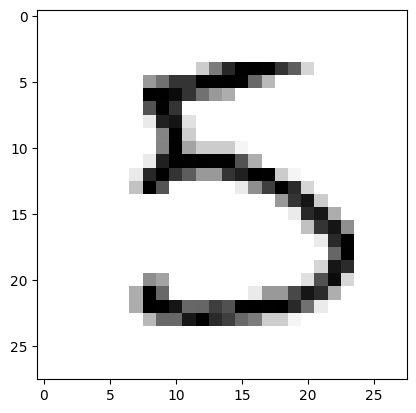

In [18]:
plt.imshow(x_test[15], cmap='binary')

**Class Imbalance:**

Ensure that the dataset does not have a significant class
imbalance that could negatively affect the model’s performance. If imbalance is
present, strategies to mitigate its effects should be considered.

Seems target labels are balanced:

In [19]:
pd.DataFrame(np.argmax(y_train, axis=1)).\
value_counts(normalize=True).sort_index() * 100
# np.argmax(y_train, axis=1).shape

,proportion
0,
0,9.871667
1,11.236667
2,9.930000
3,10.218333
4,9.736667
5,9.035000
6,9.863333
7,10.441667
8,9.751667


**Model Complexity:**

Choose an appropriate model complexity that is capable of
learning from the data without overfitting. This may involve experimenting with
different numbers of layers and units, as well as regularization techniques.


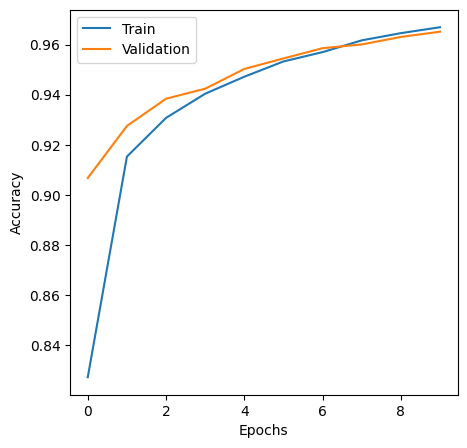

In [20]:
# plot training history details:
# print(training_hist.history)
plt.figure(figsize=(5,5))
plt.plot(training_hist.history['accuracy'])
plt.plot(training_hist.history['val_accuracy'])
plt.legend(['Train', 'Validation'])
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.show()

**Hyperparameter Tuning:**

Experiment with different hyperparameters such as
learning rate, batch size, and number of epochs to optimize the model’s
performance

Build new model with regularization to check the performce improvement

In [21]:
model2 = tf.keras.Sequential()

#input layer
ip_layer = tf.keras.layers.Flatten(input_shape=(784,))
model2.add(ip_layer)

#hidden layer-1
model2.add(tf.keras.layers.Dense(
    units=128,
    activation=tf.keras.activations.relu,
    # kernel_regularizer=tf.keras.regularizers.l2(0.002)
))

# hidden layer - 2
model2.add(tf.keras.layers.Dense(
    units=64,
    activation=tf.keras.activations.relu,
    # kernel_regularizer=tf.keras.regularizers.l2(0.002)
 ))

# output layer
model2.add(tf.keras.layers.Dense(
    units=10,
    activation=tf.keras.activations.softmax
))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [22]:
# compile model
model2_optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)
# model2_optimizer = tf.keras.optimizers.SGD(learning_rate=0.01)
model2.compile(
    optimizer=model2_optimizer,
    loss=tf.keras.losses.categorical_crossentropy,
    metrics=['accuracy','precision', 'recall', 'mse']
)

In [23]:
# train model
train_hist2 = model2.fit(
    x_train_normalized,
    y_train,
    epochs=12,
    validation_data=(x_test_normalized, y_test)
)

Epoch 1/12
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.8844 - loss: 0.3807 - mse: 0.0167 - precision: 0.9205 - recall: 0.8583 - val_accuracy: 0.9290 - val_loss: 0.2721 - val_mse: 0.0111 - val_precision: 0.9393 - val_recall: 0.9206
Epoch 2/12
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9521 - loss: 0.1714 - mse: 0.0073 - precision: 0.9611 - recall: 0.9450 - val_accuracy: 0.9495 - val_loss: 0.1899 - val_mse: 0.0078 - val_precision: 0.9600 - val_recall: 0.9421
Epoch 3/12
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9594 - loss: 0.1489 - mse: 0.0063 - precision: 0.9671 - recall: 0.9527 - val_accuracy: 0.9576 - val_loss: 0.1570 - val_mse: 0.0064 - val_precision: 0.9655 - val_recall: 0.9543
Epoch 4/12
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9656 - loss: 0.1313 - mse: 0.0053 - precision: 0.9727 - recall: 0.9597 - val_accuracy: 0.9591 - val_loss: 0.1884 - val_mse: 0.0066 - val_precision: 0.9649 - val_recall: 0.9548
Epoch 5/12
1875/1875 ━━

**Evaluation Metrics:**

Focus on accuracy as the primary evaluation metric, but
also be open to exploring other metrics that could provide additional insights into
the model’s performance.


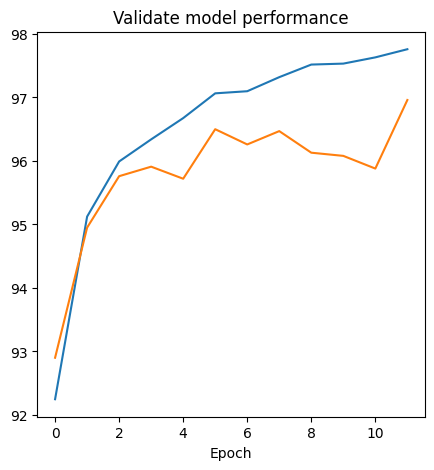

In [24]:
plt.figure(figsize=(5,5))
plt.plot(np.array(train_hist2.history['accuracy'])*100)
plt.plot(np.array(train_hist2.history['val_accuracy'])*100)
plt.title('Validate model performance')
plt.xlabel('Epoch')
plt.show()

**Predictions and Interpretability:**

Provide clear and interpretable predictions,
ensuring that the output probabilities are well-calibrated and meaningful.


In [25]:
model2.evaluate(x_test_normalized, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9636 - loss: 0.1927 - mse: 0.0057 - precision: 0.9744 - recall: 0.9588


[0.15447819232940674,
 0.9696000218391418,
 0.9778205156326294,
 0.965499997138977,
 0.0047669121995568275]

In [26]:
pred2 = model2.predict(x_test[15].reshape(1, 784))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step


In [27]:
# argmax to find the position since the result is one hot encoded
print('Digit:',np.argmax(pred2))
print('Confidance:', np.max(pred2))

Digit: 5
Confidance: 1.0


**Conclusion:**

A neural network model has been developed and trained on the well-balanced MNIST dataset, achieving an accuracy of 98% on the training set and 97% on the test set. The model demonstrated strong generalization capability when evaluated on unseen data. Further experimentation with different optimizers and hyperparameter configurations resulted in noticeable improvements in performance, highlighting the importance of model tuning in achieving optimal results.